# EDA Ecobici — plantilla

Copia este notebook como `eda_<tu_nombre>.ipynb` y trabaja tu parte aquí.
Antes de correr esto, asegúrate de haber corrido `python src/ingest.py` y `python src/stations.py` una vez.

In [ ]:
import sys
sys.path.append("../src")
import pandas as pd
import glob

paths = sorted(glob.glob("../data/raw/*.csv"))
print(paths)  # debe mostrarte tus 2 archivos, si sale vacío el problema sigue siendo la ruta

frames = [pd.read_csv(p, low_memory=False) for p in paths]
raw = pd.concat(frames, ignore_index=True)
raw.columns = [c.strip().lower().replace("_", "").replace(" ", "") for c in raw.columns]

for col in ["cicloestacionretiro", "cicloestacionarribo"]:
    vals = raw[col].astype(str)
    no_numericos = vals[~vals.str.match(r"^\d+$")]
    print(f"\n--- {col}: {len(no_numericos)} valores no numéricos ---")
    print(no_numericos.value_counts().head(20))

['../data/raw/2026-05.csv', '../data/raw/2026-06.csv']

--- cicloestacionretiro: 109824 valores no numéricos ---
cicloestacionretiro
271-272       20290
237-238       15771
158-159       11743
192-193        9876
107-108        9845
266-267        9237
273-274        9050
390-391        8939
235-236        5501
268-269        4474
445-446        2706
264-275        2145
Temporal 2      119
Temporal 1      106
Temporal 3       16
Temporal 4        6
Name: count, dtype: int64

--- cicloestacionarribo: 123965 valores no numéricos ---
cicloestacionarribo
271-272       35139
266-267       11868
158-159       11867
237-238       11744
273-274       11476
107-108        9630
192-193        8202
390-391        7588
235-236        5600
268-269        4612
264-275        3275
445-446        2659
Temporal 2      145
Temporal 1      106
Temporal 3       29
Temporal 4       25
Name: count, dtype: int64


In [10]:
stations = pd.read_csv("../data/processed/stations.csv", dtype={"station_id": "string"})
ids_validos = set(stations["station_id"])

pares = ["271-272", "237-238", "158-159", "192-193", "107-108",
         "266-267", "273-274", "390-391", "235-236", "268-269", "445-446"]

for par in pares:
    a, b = par.split("-")
    print(f"{par}: ¿{a} existe? {a in ids_validos} | ¿{b} existe? {b in ids_validos}")

271-272: ¿271 existe? True | ¿272 existe? True
237-238: ¿237 existe? True | ¿238 existe? True
158-159: ¿158 existe? True | ¿159 existe? True
192-193: ¿192 existe? True | ¿193 existe? True
107-108: ¿107 existe? True | ¿108 existe? True
266-267: ¿266 existe? True | ¿267 existe? True
273-274: ¿273 existe? True | ¿274 existe? False
390-391: ¿390 existe? True | ¿391 existe? True
235-236: ¿235 existe? True | ¿236 existe? True
268-269: ¿268 existe? True | ¿269 existe? True
445-446: ¿445 existe? True | ¿446 existe? True


## 1. Nulos

In [5]:
trips.isna().mean().sort_values(ascending=False)

estacion_destino    0.039865
estacion_origen     0.035317
edad                0.000029
genero              0.000000
bici_id             0.000000
fecha_origen        0.000000
hora_origen         0.000000
fecha_destino       0.000000
hora_destino        0.000000
origen_dt           0.000000
destino_dt          0.000000
archivo_origen      0.000000
duracion_min        0.000000
hora_del_dia        0.000000
dia_semana          0.000000
fecha               0.000000
es_fin_de_semana    0.000000
dtype: float64

## 2. Outliers de duración

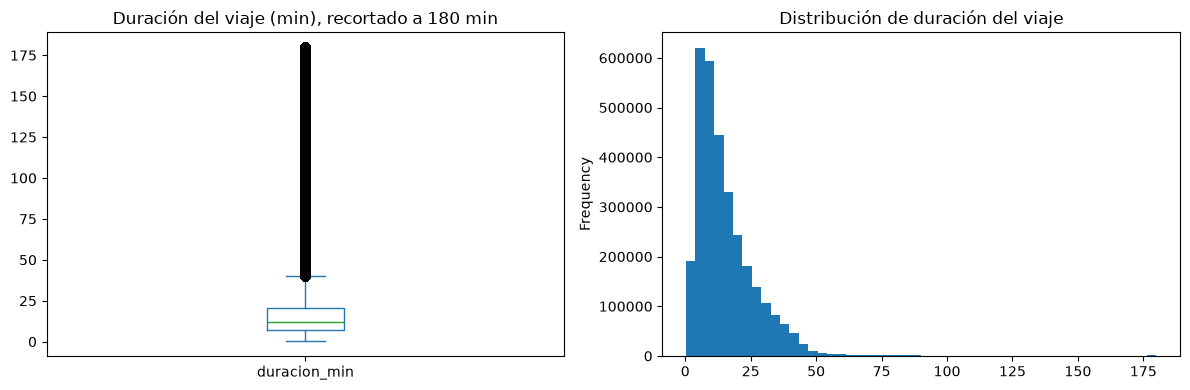

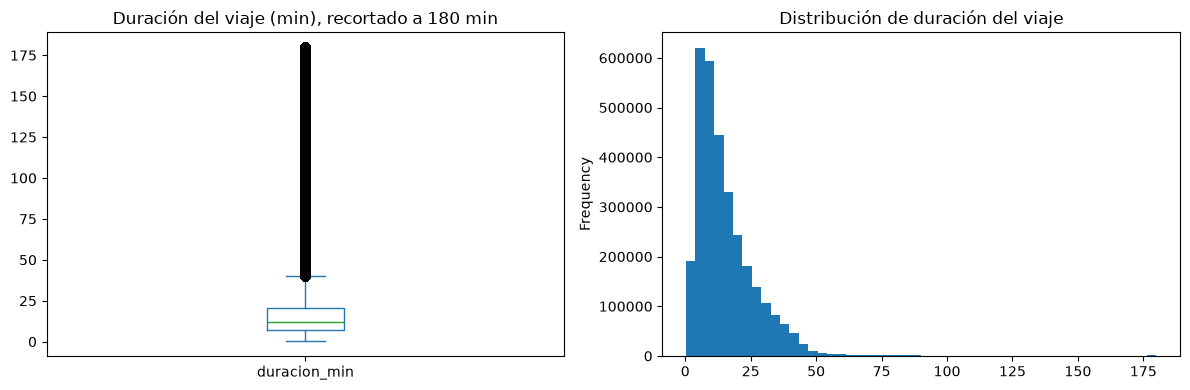

In [6]:
plot_outliers_duracion(trips)

## 3. Viajes por hora del día

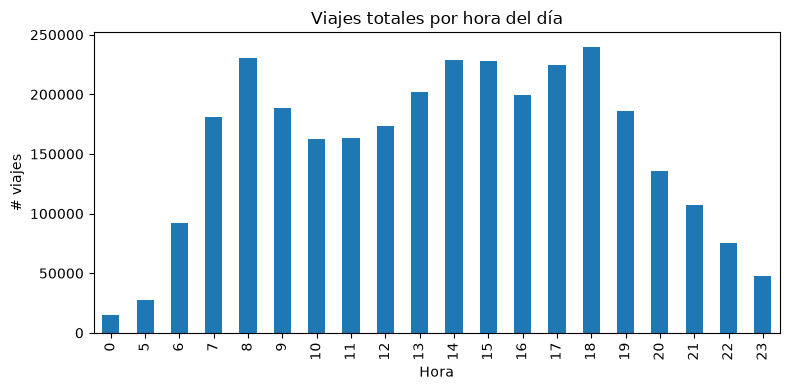

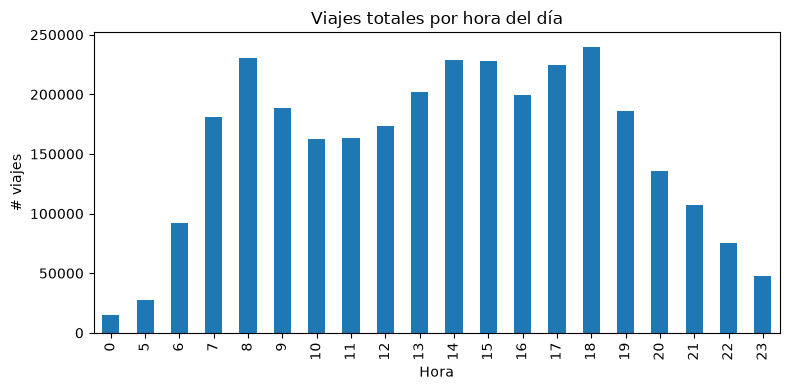

In [7]:
plot_viajes_por_hora(trips)

## 4. Top estaciones por demanda

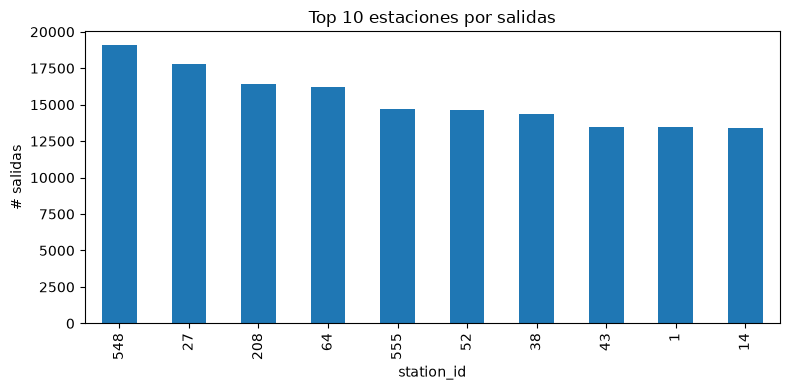

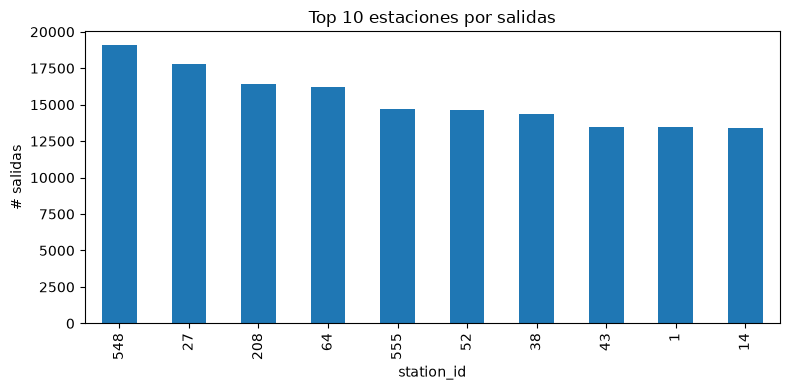

In [8]:
plot_top_estaciones(trips)

## 5. Demanda agregada estacion-fecha-hora (input para el modelo)

In [9]:
demanda = demanda_por_estacion_hora(trips)
demanda.head()

,estacion_origen,fecha,hora_del_dia,salidas
0,1,2026-04-30,23,1
1,1,2026-05-01,5,1
2,1,2026-05-01,6,6
3,1,2026-05-01,7,4
4,1,2026-05-01,8,4
